## SHBT 261 Mini project 1: Image Classification with Caltech-101 Dataset

### Author: Tzu-Hsi (Cece) Jen
### Deadline: March 3rd, 2026 


In [1]:
%pip install --upgrade kagglehub

Note: you may need to restart the kernel to use updated packages.


### 0. Dataset preparation

In [ ]:
import os
import shutil
import random
from pathlib import Path
from tqdm import tqdm
import kagglehub

# Data handling
import numpy as np
import pandas as pd
import joblib

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

# Image processing
from PIL import Image
import cv2
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog

# Machine learning (HOG + SVM)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# Deep learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD


/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# # Download latest version
# path = kagglehub.dataset_download("imbikramsaha/caltech-101")
# print("Path to dataset files:", path)

# destination = "/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data"
# shutil.move(path, destination)

In [4]:
# Load dataset

class_dir = "/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data/1/caltech-101/"

filePaths = []
labels = []

for class_name in os.listdir(class_dir): # loop through each items 
    class_path = os.path.join(class_dir, class_name)

    if not os.path.isdir(class_path):
        continue
    
    for name in os.listdir(class_path):
        if name.lower().endswith("jpg"):
            filePaths.append(os.path.join(class_path, name))
            labels.append(class_name)

df = pd.DataFrame({
    "filePath": filePaths,
    "label": labels
})

print("Total images:", len(df))
print("Total calsses:", df["label"].nunique())
df.head(2)

Total images: 9144
Total calsses: 102


,filePath,label
0,/Users/cece711/Desktop/Harvard/Year2/SHBT261/S...,gerenuk
1,/Users/cece711/Desktop/Harvard/Year2/SHBT261/S...,gerenuk


In [5]:
# Split 70/15/15

# 0.70 train 
train_df, other_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=261
)

# 0.15 validation, 0.15 test
val_df, test_df = train_test_split(
    other_df,
    test_size=0.50,
    stratify=other_df["label"],
    random_state=261
)

print("Train set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

# Save split datasets
split_dir = "/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data"
os.makedirs("/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data", exist_ok=True)

train_df.to_csv(os.path.join(split_dir, "train.csv"), index=False)
val_df.to_csv(os.path.join(split_dir, "val.csv"), index=False)
test_df.to_csv(os.path.join(split_dir, "test.csv"), index=False)

Train set: (6400, 2)
Validation set: (1372, 2)
Test set: (1372, 2)


In [6]:
train_df.head()

,filePath,label
1867,/Users/cece711/Desktop/Harvard/Year2/SHBT261/S...,joshua_tree
7618,/Users/cece711/Desktop/Harvard/Year2/SHBT261/S...,BACKGROUND_Google
3665,/Users/cece711/Desktop/Harvard/Year2/SHBT261/S...,starfish
1395,/Users/cece711/Desktop/Harvard/Year2/SHBT261/S...,airplanes
8402,/Users/cece711/Desktop/Harvard/Year2/SHBT261/S...,Faces


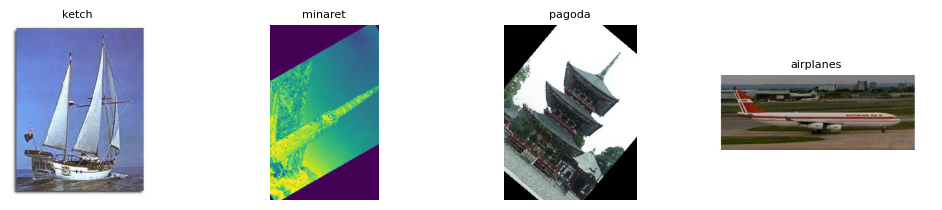

In [7]:
# Check the images
from PIL import Image
import skimage.util

# random images
img_paths = train_df["filePath"].tolist()
sample_paths = random.sample(img_paths, 4)

plt.figure(figsize=(10,6))

for i, p in enumerate(sample_paths):
    img = Image.open(p)
    label = os.path.basename(os.path.dirname(p))

    plt.subplot(3, 4, i+1)
    plt.imshow(img)
    plt.title(label, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

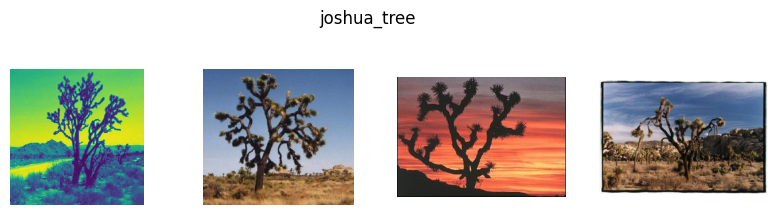

In [8]:
# images of specific class
class_name = "joshua_tree"
class_folder = os.path.join(class_dir, class_name)
files = os.listdir(class_folder)[:4]

plt.figure(figsize=(10,6))

for i, f in enumerate(files):
    img = Image.open(os.path.join(class_folder, f))

    plt.subplot(3, 4, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle(class_name)
plt.show()

In [9]:
# Check label distribution

label_counts = train_df["label"].value_counts().reset_index()
label_counts.columns = ["label", "count"]

label_bar = (
    alt.Chart(label_counts)
    .mark_bar()
    .encode(
        x=alt.X(
            "label:N",
            title="Label",
            sort="-y",  
            axis=alt.Axis(labelAngle=90, labelFontSize=7)
        ),
        y=alt.Y("count:Q", title="Count"),
        tooltip=[
            alt.Tooltip("label:N", title="Label"),
            alt.Tooltip("count:Q", title="Count")
        ]
    )
    .properties(title="Label Distribution")
)

label_bar

alt.Chart(...)

In [10]:
# Create train, val, and test folders

# Define directories
base_dir = pathlib.Path("/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data/1/caltech-101")
out_dir = pathlib.Path("/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data")

# Split ratio
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

random.seed(261)

categories = [d.name for d in base_dir.iterdir() if d.is_dir()]

for c in categories:
    print(f"Processing {c}")

    # Get filenames
    fnames = [p for p in (base_dir/c).iterdir() if p.is_file()]
    random.shuffle(fnames)

    # Split datasets
    n = len(fnames)
    train_end = int(n*train_ratio)
    val_end = train_end + int(n*val_ratio)

    # Train
    train_dir = out_dir/"train"/c
    train_dir.mkdir(parents=True, exist_ok=True)
    for f in fnames[:train_end]:
       shutil.copyfile(src=f,
                       dst=train_dir/f.name)
       
    # Validation
    val_dir = out_dir/"val"/c
    val_dir.mkdir(parents=True, exist_ok=True)
    for f in fnames[train_end:val_end]:
       shutil.copyfile(src=f,
                       dst=val_dir/f.name)
       
    # Test
    test_dir = out_dir/"test"/c
    test_dir.mkdir(parents=True, exist_ok=True)
    for f in fnames[val_end:]:
       shutil.copyfile(src=f,
                       dst=test_dir/f.name)

print("Split folders created!")

Processing gerenuk
Processing hawksbill
Processing headphone
Processing ant
Processing butterfly
Processing lamp
Processing strawberry
Processing water_lilly
Processing chandelier
Processing dragonfly
Processing crab
Processing pagoda
Processing dollar_bill
Processing emu
Processing inline_skate
Processing platypus
Processing dalmatian
Processing cup
Processing airplanes
Processing joshua_tree
Processing cougar_body
Processing grand_piano
Processing trilobite
Processing brontosaurus
Processing wild_cat
Processing pigeon
Processing dolphin
Processing soccer_ball
Processing wrench
Processing scorpion
Processing flamingo_head
Processing nautilus
Processing accordion
Processing cougar_face
Processing pyramid
Processing camera
Processing barrel
Processing schooner
Processing cellphone
Processing panda
Processing revolver
Processing lobster
Processing menorah
Processing lotus
Processing stapler
Processing crocodile
Processing chair
Processing helicopter
Processing minaret
Processing starfish